# Predicting Light Echo Evolution with ConvLSTM

## Overview

Light echoes are not static structures. As light from a transient event propagates through space and scatters off surrounding dust, the observed echo morphology changes continuously with time.

Understanding how light echoes evolve is important for:
- Predicting future echo locations and structures.
- Recovering missing observations.
- Planning follow-up observations.
- Exploring the 3D structure of the interstellar medium.

In this notebook, we use a **Convolutional Long Short-Term Memory Network (ConvLSTM)** to learn the temporal evolution of light echoes from a sequence of astronomical images.

The model learns how light echo structures change over time and predicts future observations based on previous images.


Traditional convolutional neural networks (CNNs) are effective at learning spatial patterns but do not model time evolution.

ConvLSTM combines:
- **Convolutional layers** to learn spatial structures.
- **LSTM memory cells** to learn temporal evolution.

This makes it suitable for modeling evolving astronomical phenomena.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# change path
%cd /content/drive/MyDrive/ztf_summer_school_2026/day3/le_study/

/content/drive/MyDrive/ztf_summer_school_2026


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.optim as optim
from torch.utils.data import DataLoader


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
torch.__version__

'2.11.0+cu128'

## create toy dataset

In [ ]:

def generate_echo_sequence(
    num_frames=100,
    size=128,
    center=None,
    velocity=1.2,
    sigma=3.0,
    decay=0.99
):
    """
    Expanding ring (light echo-like)
    """
    if center is None:
        center = (size // 2, size // 2)

    y, x = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
    cx, cy = center

    sequence = []

    for t in range(num_frames):
        r = velocity * t

        dist = np.sqrt((x - cx)**2 + (y - cy)**2)

        # Gaussian ring
        img = np.exp(-((dist - r)**2) / (2 * sigma**2))

        # brightness decay
        img *= decay**t

        sequence.append(img.astype(np.float32))

    return np.stack(sequence)  # (T, H, W)

In [ ]:
def generate_multi_echo(
    num_frames=100,
    size=128,
    n_rings=3
):
    data = np.zeros((num_frames, size, size), dtype=np.float32)

    for i in range(n_rings):
        seq = generate_echo_sequence(
            num_frames=num_frames,
            size=size,
            velocity=0.5 + i * 0.5,
            sigma=2.0 + i
        )
        data += seq

    # add noise
    noise = np.random.normal(0, 0.05, data.shape)
    data += noise.astype(np.float32)

    return data

In [ ]:
data = generate_echo_sequence(num_frames=100, size=128)

data = generate_multi_echo(num_frames=100, size=128, n_rings=1)
print(data.shape)  # (100, 128, 128)

(100, 128, 128)


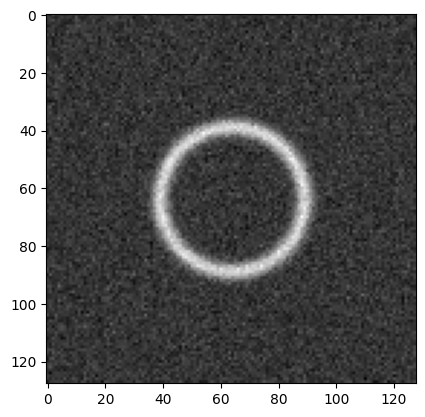

In [ ]:
plt.imshow(data[50], cmap="gray")

## dataset

In [ ]:

class ToyDataset(Dataset):
    def __init__(self, data, T=5):
        self.data = data
        self.T = T

    def __len__(self):
        return len(self.data) - self.T - 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.T]        # (T,H,W)
        y = self.data[idx+self.T]            # (H,W)

        x = torch.tensor(x).unsqueeze(1)     # (T,1,H,W)
        y = torch.tensor(y).unsqueeze(0)     # (1,H,W)

        return x.float(), y.float()

## model

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, in_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)         # 512 -> 512
        self.pool1 = nn.MaxPool2d(2)                      # 512 -> 256

        self.enc2 = DoubleConv(base, base * 2)           # 256 -> 256
        self.pool2 = nn.MaxPool2d(2)                      # 256 -> 128

        self.enc3 = DoubleConv(base * 2, base * 4)       # 128 -> 128
        self.pool3 = nn.MaxPool2d(2)                      # 128 -> 64

        self.enc4 = DoubleConv(base * 4, base * 8)       # 64 -> 64

    def forward(self, x):
        x1 = self.enc1(x)                 # (B, 32, 512, 512)
        x2 = self.enc2(self.pool1(x1))    # (B, 64, 256, 256)
        x3 = self.enc3(self.pool2(x2))    # (B, 128, 128, 128)
        x4 = self.enc4(self.pool3(x3))    # (B, 256, 64, 64)
        return x1, x2, x3, x4

In [ ]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim

        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            4 * hidden_dim,
            kernel_size=kernel_size,
            padding=padding
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)

        i, f, o, g = torch.chunk(gates, 4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next

    def init_hidden(self, batch_size, spatial_size, device):
        H, W = spatial_size
        h = torch.zeros(batch_size, self.hidden_dim, H, W, device=device)
        c = torch.zeros(batch_size, self.hidden_dim, H, W, device=device)
        return h, c

In [ ]:
class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)

    def forward(self, x_seq):
        """
        x_seq: (B, T, C, H, W)
        returns: final hidden state (B, hidden_dim, H, W)
        """
        B, T, C, H, W = x_seq.shape
        device = x_seq.device

        h, c = self.cell.init_hidden(B, (H, W), device)

        for t in range(T):
            h, c = self.cell(x_seq[:, t], h, c)

        return h

In [ ]:
class Decoder(nn.Module):
    def __init__(self, out_channels=1, base=32, latent_channels=256):
        super().__init__()

        self.up1 = nn.ConvTranspose2d(latent_channels, base * 4, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 4 + base * 4, base * 4)   # x + skip x3

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 2 + base * 2, base * 2)   # x + skip x2

        self.up3 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base + base, base)                # x + skip x1

        self.out = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, latent, x3, x2, x1):
        x = self.up1(latent)              # 64 -> 128
        x = torch.cat([x, x3], dim=1)
        x = self.dec1(x)

        x = self.up2(x)                   # 128 -> 256
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.up3(x)                   # 256 -> 512
        x = torch.cat([x, x1], dim=1)
        x = self.dec3(x)

        return self.out(x)

In [ ]:
class UNetConvLSTM(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base=32, hidden_dim=256):
        super().__init__()

        self.encoder = Encoder(in_channels=in_channels, base=base)
        self.temporal = ConvLSTM(input_dim=base * 8, hidden_dim=hidden_dim, kernel_size=3)
        self.latent_proj = nn.Conv2d(hidden_dim, base * 8, kernel_size=1)
        self.decoder = Decoder(out_channels=out_channels, base=base, latent_channels=base * 8)

    def forward(self, x_seq, return_latent=False):
        """
        x_seq: (B, T, C, H, W)
        B: batch size
        T: sequence length
        C: number of channels
        H: height
        W: width
        Output: (B, out_channels, H, W)
        """
        B, T, C, H, W = x_seq.shape

        encoded_seq = []
        skip1, skip2, skip3 = [], [], []

        for t in range(T):
            x1, x2, x3, x4 = self.encoder(x_seq[:, t])
            skip1.append(x1)
            skip2.append(x2)
            skip3.append(x3)
            encoded_seq.append(x4)

        encoded_seq = torch.stack(encoded_seq, dim=1)   # (B, T, 256, 64, 64)

        latent = self.temporal(encoded_seq)             # (B, hidden_dim, 64, 64)
        latent = self.latent_proj(latent)               # (B, 256, 64, 64)

        # use skip connections from the LAST observed frame
        x1_last = skip1[-1]
        x2_last = skip2[-1]
        x3_last = skip3[-1]

        out = self.decoder(latent, x3_last, x2_last, x1_last)

        if return_latent:
            return out, latent
        return out

In [ ]:

model = UNetConvLSTM(
    in_channels=1,   # change if you have multiple channels
    out_channels=1,
    base=32,
    hidden_dim=128   # 128 is a good starting point
).to(device)

x = torch.randn(2, 5, 1, 512, 512).to(device)   # batch of 2 samples
y = model(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([2, 5, 1, 512, 512])
Output shape: torch.Size([2, 1, 512, 512])


## train on toy dataset

In [ ]:
#data = generate_echo_sequence(100, 256, velocity=1.2)
#data = generate_echo_sequence(num_frames=100, size=128)
data = generate_multi_echo(num_frames=100, size=128, n_rings=1)

T = 5
train_data = data[:40]
val_data   = data[40:50]
test_data  = data[50:]

train_ds = ToyDataset(train_data, T)
val_ds   = ToyDataset(val_data, T)
test_ds  = ToyDataset(test_data, T)

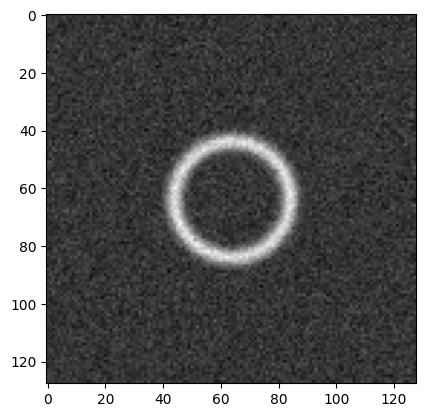

In [ ]:
plt.imshow(data[40, :, :], cmap='gray')

In [ ]:

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False)

In [ ]:
model = UNetConvLSTM(
    in_channels=1,   # change if you have multiple channels
    out_channels=1,
    base=16,
    hidden_dim=128,   # 128 is a good starting point
).to(device)


In [ ]:
criterion = nn.L1Loss()   # better than MSE for images

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

train_loss_hist = []
val_loss_hist = []


n_epochs = 100

for epoch in range(n_epochs):
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    train_loss_hist.append(train_loss)
    # --- validation ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            val_loss += criterion(pred, y).item()

    val_loss /= len(val_loader)
    val_loss_hist.append(val_loss)


    print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")


Epoch 0: train=0.1574, val=0.1621
Epoch 1: train=0.1445, val=0.1493
Epoch 2: train=0.1310, val=0.1350
Epoch 3: train=0.1147, val=0.1141
Epoch 4: train=0.0857, val=0.0702
Epoch 5: train=0.0609, val=0.0655
Epoch 6: train=0.0560, val=0.0638
Epoch 7: train=0.0539, val=0.0617
Epoch 8: train=0.0529, val=0.0603
Epoch 9: train=0.0517, val=0.0578
Epoch 10: train=0.0504, val=0.0552
Epoch 11: train=0.0489, val=0.0522
Epoch 12: train=0.0473, val=0.0497
Epoch 13: train=0.0459, val=0.0478
Epoch 14: train=0.0450, val=0.0466
Epoch 15: train=0.0443, val=0.0456
Epoch 16: train=0.0439, val=0.0450
Epoch 17: train=0.0435, val=0.0445
Epoch 18: train=0.0432, val=0.0441
Epoch 19: train=0.0429, val=0.0438
Epoch 20: train=0.0428, val=0.0436
Epoch 21: train=0.0426, val=0.0434
Epoch 22: train=0.0425, val=0.0433
Epoch 23: train=0.0424, val=0.0433
Epoch 24: train=0.0423, val=0.0430
Epoch 25: train=0.0421, val=0.0432
Epoch 26: train=0.0421, val=0.0438
Epoch 27: train=0.0420, val=0.0430
Epoch 28: train=0.0418, val=0.

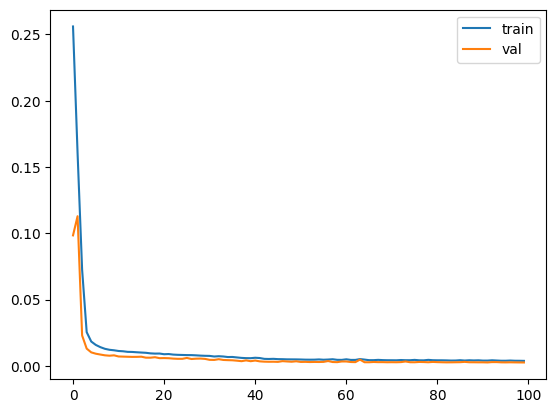

In [ ]:
plt.plot(train_loss_hist, label="train")
plt.plot(val_loss_hist, label="val")
plt.legend()
plt.show()

In [ ]:
x, y = train_ds[20]
x = x.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred = model(x).cpu().squeeze().numpy()



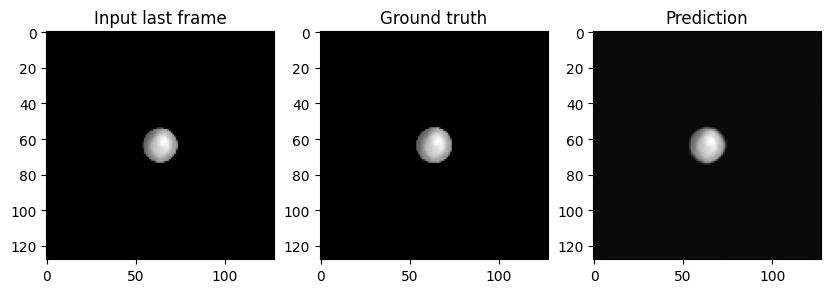

In [ ]:

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Input last frame")
plt.imshow(x[0,-1,0].cpu(), cmap='gray')

plt.subplot(1,3,2)
plt.title("Ground truth")
plt.imshow(y.squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')

plt.show()

In [ ]:

def rollout(model, init_seq, steps=5):
    model.eval()
    device = next(model.parameters()).device

    seq = init_seq.clone().to(device)
    preds = []

    for _ in range(steps):
        with torch.no_grad():
            pred = model(seq)

        preds.append(pred.cpu())
        seq = torch.cat([seq[:,1:], pred.unsqueeze(1)], dim=1)

    return preds

In [ ]:

def plot_rollout(model, dataset, idx=0, steps=5, device="cpu"):
    # get initial sequence
    x, _ = dataset[idx]
    x = x.unsqueeze(0).to(device)  # (1,T,1,H,W)

    # rollout predictions
    preds = rollout(model, x, steps=steps,)

    # ground truth frames
    gt_frames = []
    for i in range(steps):
        _, y = dataset[idx + i]
        gt_frames.append(y)

    # plot
    plt.figure(figsize=(3*steps, 6))

    for i in range(steps):
        # ground truth
        plt.subplot(2, steps, i+1)
        plt.imshow(gt_frames[i].squeeze(), cmap='gray')
        plt.title(f"GT t+{i+1}")
        plt.axis('off')

        # prediction
        plt.subplot(2, steps, steps+i+1)
        plt.imshow(preds[i].squeeze(), cmap='gray')
        plt.title(f"Pred t+{i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    return gt_frames, preds

In [ ]:
len(test_ds)

44

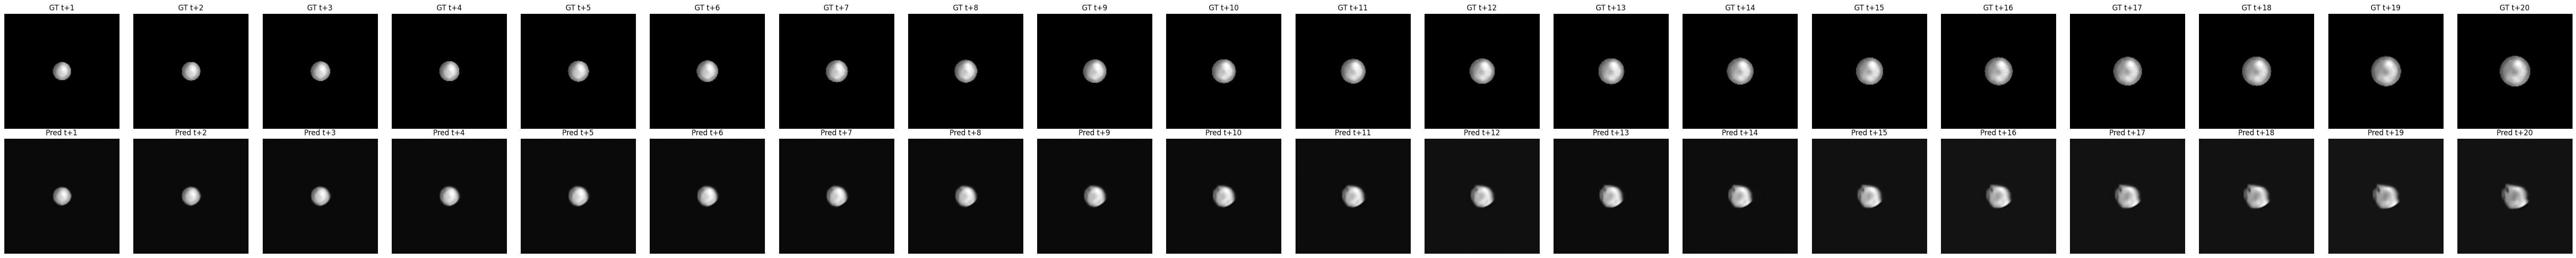

In [ ]:
gt_frames, preds = plot_rollout(model, train_ds, idx=20, steps=20, device=device)

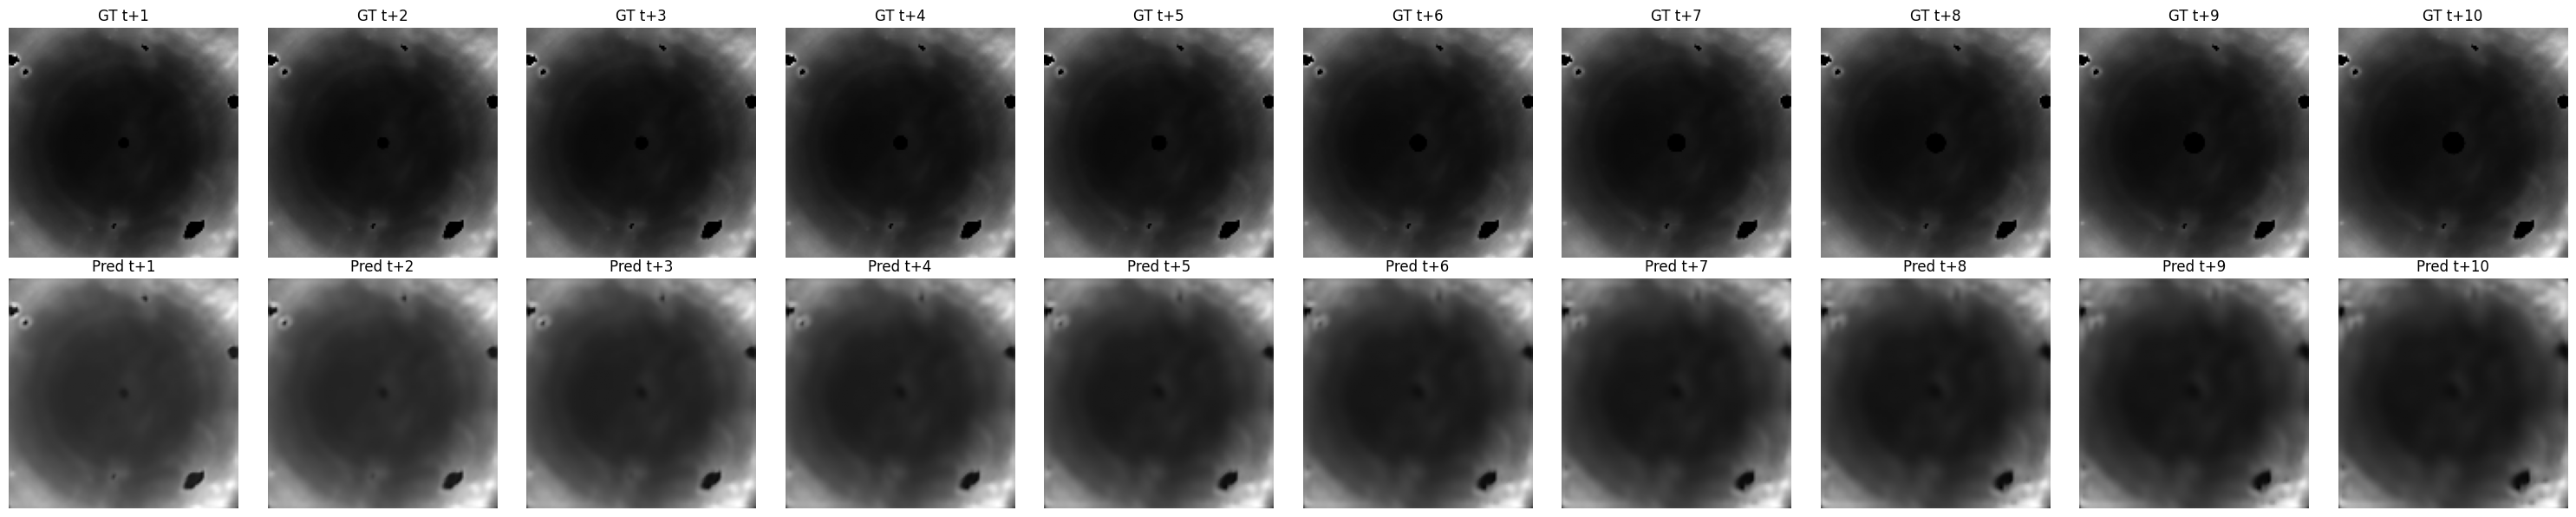

In [ ]:
gt_frames, preds = plot_rollout(model, val_ds, idx=0, steps=10, device=device)

### Explore latent space

In [ ]:
def plot_latent_maps(latent):
    # latent: (1, C, H, W)
    #latent = latent.squeeze().cpu().numpy()

    #import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))
    for i in range(8):  # show first 8 channels
        plt.subplot(2,4,i+1)
        plt.imshow(latent[i], cmap='viridis')
        plt.title(f"ch {i}")
        plt.axis('off')

    plt.show()

In [ ]:
def get_latents(model, dataset, device="cpu"):
    latents = []

    model.eval()
    with torch.no_grad():
        for i in range(len(dataset)):
            x, _ = dataset[i]
            x = x.unsqueeze(0).to(device)

            _, latent = model(x, return_latent=True)

            latents.append(latent.cpu().numpy())
    return latents


In [ ]:
from sklearn.decomposition import PCA

def latent_pca(model, dataset, device="cpu"):
    latents = []

    model.eval()
    with torch.no_grad():
        for i in range(len(dataset)):
            x, _ = dataset[i]
            x = x.unsqueeze(0).to(device)

            _, latent = model(x, return_latent=True)

            latents.append(latent.flatten().cpu().numpy())

    latents = np.stack(latents)

    pca = PCA(n_components=2)
    z = pca.fit_transform(latents)

    return latents, z

In [ ]:
#latents, z = latent_pca(model, train_ds, device=device)

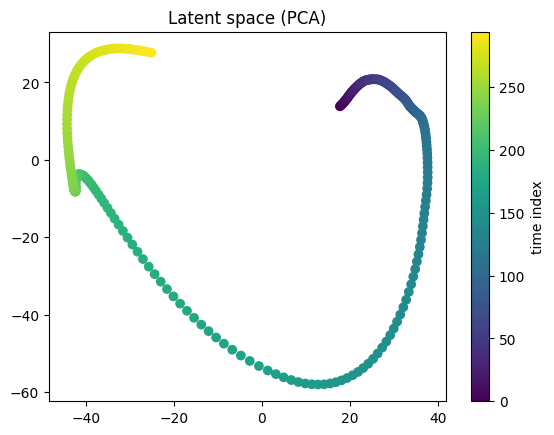

In [ ]:
latents, z = latent_pca(model, train_ds, device)

plt.scatter(z[:,0], z[:,1], c=np.arange(len(z)), cmap='viridis')
plt.colorbar(label="time index")
plt.title("Latent space (PCA)")
plt.show()



In [ ]:
#latents = get_latents(model, train_ds, device=device)

In [ ]:
def latent_trajectory(model, data, device="cpu"):
    traj = []

    model.eval()
    with torch.no_grad():
        for t in range(len(data)-5):
            x = torch.tensor(data[t:t+5]).unsqueeze(0).unsqueeze(2).to(device)

            _, latent = model(x, return_latent=True)
            traj.append(latent.flatten().cpu().numpy())

    traj = np.stack(traj)

    pca = PCA(n_components=2)
    z = pca.fit_transform(traj)

    plt.plot(z[:,0], z[:,1], '-', alpha=.5)

    plt.scatter(z[:,0], z[:,1], c=np.arange(len(z)), cmap='viridis')

    plt.colorbar(label="time index")

    plt.title("Latent trajectory over time")
    plt.show()

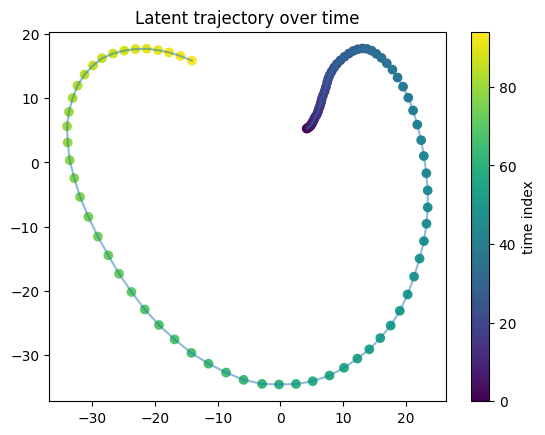

In [ ]:
latent_trajectory(model, data, device=device)



## train on simulated images

In [ ]:
LE_sim = np.load("./dataset/LEsim/LEsim_sn2014J.npz")

LE_sim.keys()

KeysView(NpzFile './dataset/LEsim/LEsim_sn2014J.npz' with keys: spitzer_cutout, f_bg, F_le_stack)

In [ ]:
F_le_stack = LE_sim['F_le_stack']

f_bg = LE_sim['f_bg']

In [ ]:
F_le_stack.shape

(512, 512, 500)

In [ ]:
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F


class LightEchoDataset(Dataset):
    def __init__(self, F_le_stack, seq_len=5, resize=128):
        """
        Dataset for light echo temporal prediction.

        Parameters
        ----------
        F_le_stack : numpy array
            Light echo cube with shape (H, W, T)
            Example: (512, 512, 500)

        seq_len : int
            Number of input frames

        resize : int
            Output image size
        """

        self.seq_len = seq_len
        self.resize = resize

        # convert to tensor
        # (H,W,T) -> (T,H,W)
        self.data = torch.tensor(
            F_le_stack.transpose(2,0,1),
            dtype=torch.float32
        )

        # normalize
        self.data = (self.data - self.data.min()) / (
            self.data.max() - self.data.min()
        )

        # add channel dimension
        # (T,H,W) -> (T,1,H,W)
        self.data = self.data.unsqueeze(1)


    def __len__(self):

        # number of possible sequences
        return self.data.shape[0] - self.seq_len


    def __getitem__(self, idx):

        # input sequence
        x = self.data[
            idx:idx+self.seq_len
        ]

        # next frame as target
        y = self.data[
            idx+self.seq_len
        ]

        # resize
        x = F.interpolate(
            x,
            size=(self.resize,self.resize),
            mode='bilinear',
            align_corners=False
        )

        y = F.interpolate(
            y.unsqueeze(0),
            size=(self.resize,self.resize),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)


        return x, y

In [ ]:
F_train = F_le_stack[:,:, :300]

F_val = F_le_stack[:,:,300:]

In [ ]:
train_ds = LightEchoDataset(
    F_train,
    seq_len=5,
    resize=128
)

val_ds = LightEchoDataset(
    F_val,
    seq_len=5,
    resize=128
)

In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False
)

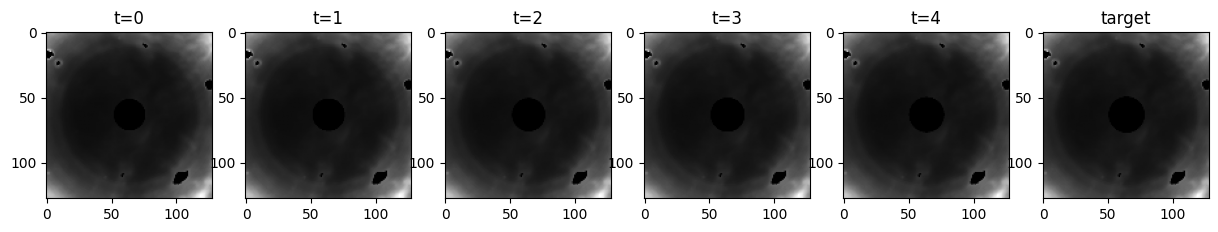

In [ ]:

x, y = val_ds[30]

fig, axes = plt.subplots(1,6,figsize=(15,3))

for i in range(5):
    axes[i].imshow(x[i,0], cmap='gray')
    axes[i].set_title(f"t={i}")

axes[5].imshow(y[0], cmap='gray')
axes[5].set_title("target")

plt.show()

In [ ]:
model = UNetConvLSTM(
    in_channels=1,   # change if you have multiple channels
    out_channels=1,
    base=16,
    hidden_dim=128,   # 128 is a good starting point
).to(device)

criterion = nn.L1Loss()   # better than MSE for images

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:

train_loss_hist = []
val_loss_hist = []


n_epochs = 100

for epoch in range(n_epochs):
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    train_loss_hist.append(train_loss)
    # --- validation ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            val_loss += criterion(pred, y).item()

    val_loss /= len(val_loader)
    val_loss_hist.append(val_loss)


    print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")


Epoch 0: train=0.2559, val=0.0984
Epoch 1: train=0.1605, val=0.1129
Epoch 2: train=0.0724, val=0.0230
Epoch 3: train=0.0255, val=0.0131
Epoch 4: train=0.0184, val=0.0102
Epoch 5: train=0.0158, val=0.0092
Epoch 6: train=0.0142, val=0.0086
Epoch 7: train=0.0129, val=0.0080
Epoch 8: train=0.0122, val=0.0077
Epoch 9: train=0.0118, val=0.0080
Epoch 10: train=0.0113, val=0.0071
Epoch 11: train=0.0111, val=0.0070
Epoch 12: train=0.0106, val=0.0069
Epoch 13: train=0.0105, val=0.0068
Epoch 14: train=0.0103, val=0.0068
Epoch 15: train=0.0101, val=0.0070
Epoch 16: train=0.0099, val=0.0062
Epoch 17: train=0.0095, val=0.0062
Epoch 18: train=0.0093, val=0.0066
Epoch 19: train=0.0093, val=0.0059
Epoch 20: train=0.0088, val=0.0059
Epoch 21: train=0.0090, val=0.0058
Epoch 22: train=0.0086, val=0.0055
Epoch 23: train=0.0084, val=0.0054
Epoch 24: train=0.0083, val=0.0054
Epoch 25: train=0.0082, val=0.0060
Epoch 26: train=0.0082, val=0.0052
Epoch 27: train=0.0080, val=0.0055
Epoch 28: train=0.0078, val=0.